In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os 
from pathlib import Path
import xgboost as xgb

In [3]:
X = []
Y = []
for conc in np.arange(2,53,2):
    for config in range(10000):
        file = np.load(os.path.expanduser(f"~/transmission_results/size_9_{conc}/9_agnr_conc{conc}_cfg{config}.npy"))[:150]
        X.append(file)
        Y.append(conc)
X = np.array(X)  # Shape: (260000, 150)
Y = np.array(Y)  # Shape: (260000,)

In [4]:
database = pd.DataFrame(X, columns=[f"signal_{i}" for i in range(150)])

In [5]:
database["target"] = Y

In [ ]:
database.head(2)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold

In [7]:
y_target = database["target"]
X_target= database.drop(columns=["target"])

In [19]:
x_train,x_test,y_train,y_test = train_test_split(X_target,y_target,random_state=42,train_size=0.8,shuffle=True)

In [11]:
print(x_train.shape)
print(y_train.shape)

(208000, 150)
(208000,)


In [20]:
print(f"x_train length: {len(x_train)} | y_train length: {len(y_train)}")
assert len(x_train) == len(y_train), "Lengths do not match!"

x_train length: 208000 | y_train length: 208000


In [22]:
model = xgb.XGBRegressor(
    n_estimators = 1000,
    learning_rate = 0.01,
    max_depth = 12,
    subsample = 0.8,
    colsample_bytree=0.8,
    tree_method="hist",        # Hardware-accelerated histogram algorithm
    random_state=42,
    n_jobs=-1
)

In [24]:
model.fit(x_train,y_train,eval_set=[(x_test,y_test)])

[0]	validation_0-rmse:14.84690
[1]	validation_0-rmse:14.70663
[2]	validation_0-rmse:14.56776
[3]	validation_0-rmse:14.43050
[4]	validation_0-rmse:14.29456
[5]	validation_0-rmse:14.15996
[6]	validation_0-rmse:14.02651
[7]	validation_0-rmse:13.89464
[8]	validation_0-rmse:13.76408
[9]	validation_0-rmse:13.63476
[10]	validation_0-rmse:13.50677
[11]	validation_0-rmse:13.37993
[12]	validation_0-rmse:13.25418
[13]	validation_0-rmse:13.12987
[14]	validation_0-rmse:13.00671
[15]	validation_0-rmse:12.88469
[16]	validation_0-rmse:12.76405
[17]	validation_0-rmse:12.64440
[18]	validation_0-rmse:12.52627
[19]	validation_0-rmse:12.40912
[20]	validation_0-rmse:12.29314
[21]	validation_0-rmse:12.17836
[22]	validation_0-rmse:12.06457
[23]	validation_0-rmse:11.95198
[24]	validation_0-rmse:11.84058
[25]	validation_0-rmse:11.73025
[26]	validation_0-rmse:11.62117
[27]	validation_0-rmse:11.51309
[28]	validation_0-rmse:11.40616
[29]	validation_0-rmse:11.30016
[30]	validation_0-rmse:11.19526
[31]	validation_0-

KeyboardInterrupt: 

In [25]:
param_grid = {
    "max_depth": [3, 6, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "tree_method": ["hist"]  # 'hist' is fastest for large tabular/sequence datasets
}

In [33]:
base_model = xgb.XGBRegressor(
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
            # Use "cpu" if no CUDA GPU is available
    random_state=42
)

In [34]:
from sklearn.model_selection import GridSearchCV, KFold

In [35]:
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)

In [36]:
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_strategy,
    verbose=False,
    n_jobs=-1  # Parallelize across CPU workers
)

In [37]:
print("Starting GridSearch hyperparameter optimization...\n")
grid_search.fit(x_train, y_train)

# 6. Output Best Parameters and Results
best_rmse = -grid_search.best_score_
print("\n" + "="*50)
print(f"Best CV RMSE: {best_rmse:.4f}")
print("Best Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  • {param}: {value}")
print("="*50)

Starting GridSearch hyperparameter optimization...




Best CV RMSE: 1.5516
Best Hyperparameters:
  • learning_rate: 0.05
  • max_depth: 9
  • tree_method: hist


In [39]:
best_model = grid_search.best_estimator_

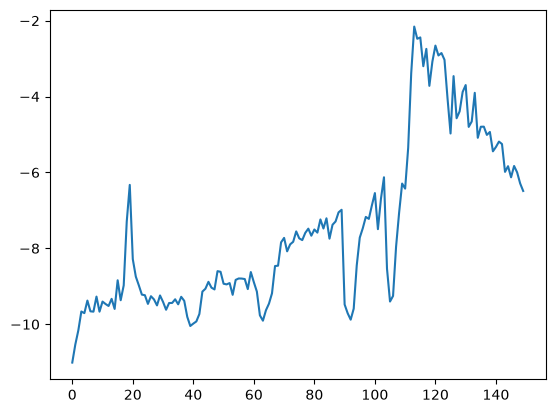

In [42]:
plt.plot(np.log(best_model.feature_importances_))

In [38]:
# Convert grid search results into a readable pandas DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Select and format key columns
clean_results = results_df[[
    "param_max_depth", 
    "param_learning_rate", 
    "param_tree_method", 
    "mean_test_score", 
    "std_test_score", 
    "rank_test_score"
]].copy()

# Convert negative RMSE back to positive RMSE
clean_results["mean_rmse"] = -clean_results["mean_test_score"]
clean_results = clean_results.drop(columns=["mean_test_score"]).sort_values("rank_test_score")

print(clean_results.head(10).to_string(index=False))

 param_max_depth  param_learning_rate param_tree_method  std_test_score  rank_test_score  mean_rmse
               9                 0.05              hist        0.004472                1   1.551564
               9                 0.10              hist        0.006806                2   1.589270
               6                 0.05              hist        0.004170                3   1.661669
               6                 0.10              hist        0.004659                4   1.676648
               3                 0.10              hist        0.004660                5   1.835201
               3                 0.05              hist        0.003196                6   1.844051
               9                 0.01              hist        0.005593                7   2.006502
               6                 0.01              hist        0.006466                8   2.190641
               3                 0.01              hist        0.007746                9   2.630689


In [13]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
rmse_scores, r2_scores = [], []

In [14]:
print("Training XGBoost with 5-Fold Cross-Validation...\n")

Training XGBoost with 5-Fold Cross-Validation...



In [21]:
for fold, (train_idx, val_idx) in enumerate(kf.split(x_train, y_train), 1):
    X_tr, X_va = x_train.iloc[train_idx], x_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )

    preds = model.predict(X_va)
    rmse = root_mean_squared_error(y_va, preds)
    r2 = r2_score(y_va, preds)

    rmse_scores.append(rmse)
    r2_scores.append(r2)
    print(f"Fold {fold} | Validation RMSE: {rmse:.4f} | R²: {r2:.4f}")

print(f"\nMean CV RMSE: {np.mean(rmse_scores):.4f} (± {np.std(rmse_scores):.4f})")
print(f"Mean CV R²:   {np.mean(r2_scores):.4f}")

Fold 1 | Validation RMSE: 13.7053 | R²: 0.1649
Fold 2 | Validation RMSE: 13.7295 | R²: 0.1651


KeyboardInterrupt: 

In [43]:
import numpy as np
import optuna
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

# Suppress Optuna's default verbose logging per iteration (optional)
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # 1. Define the hyperparameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),   # L1 regularization
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True), # L2 regularization
        "tree_method": "hist",
        "device": "cuda",        # Set to "cpu" if running without GPU
        "random_state": 42,
        "n_jobs": -1
    }
    
    # 2. Evaluate hyperparameters using 3-fold Cross-Validation
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    rmse_scores = []
    
    for train_idx, val_idx in kf.split(x_train, y_train):
        X_tr, X_va = x_train.iloc[train_idx], x_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = xgb.XGBRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )
        
        preds = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, preds)
        rmse_scores.append(rmse)
        
    return np.mean(rmse_scores)


# 3. Create and run Optuna study
print("Starting Bayesian Optimization with Optuna...\n")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, timeout=1200)  # 30 trials or 20 min max

# 4. Display Best Parameters
print("\n" + "="*50)
print(f"Best Validation RMSE: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  • {key}: {value if isinstance(value, int) else f'{value:.6f}'}")
print("="*50)

Starting Bayesian Optimization with Optuna...



/home/shardul/miniconda3/envs/ml/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:08:52] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/home/shardul/miniconda3/envs/ml/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:08:52] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/home/shardul/miniconda3/envs/ml/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:11:08] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/home/shardul/miniconda3/envs/ml/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:11:08] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we cou


Best Validation RMSE: 1.5175
Best Hyperparameters:
  • n_estimators: 400
  • max_depth: 10
  • learning_rate: 0.046404
  • subsample: 0.827830
  • colsample_bytree: 0.522566
  • reg_alpha: 0.531350
  • reg_lambda: 0.296229


In [44]:
from sklearn.metrics import r2_score

# Re-train using optimal parameters found by Optuna
best_params = study.best_params
best_params.update({
    "tree_method": "hist",
    "device": "cuda",
    "random_state": 42
})

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(x_train, y_train)

# Evaluate on test set
test_preds = final_model.predict(x_test)
test_rmse = root_mean_squared_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

print(f"Test Set RMSE: {test_rmse:.4f}")
print(f"Test Set R²:   {test_r2:.4f}")

/home/shardul/miniconda3/envs/ml/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:28:54] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/home/shardul/miniconda3/envs/ml/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:28:54] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Test Set RMSE: 1.4486
Test Set R²:   0.9907


In [45]:
import optuna.visualization as vis

# Plot hyperparameter importance (requires plotly installed)
fig = vis.plot_param_importances(study)
fig.show()

# Plot optimization history across trials
fig_history = vis.plot_optimization_history(study)
fig_history.show()

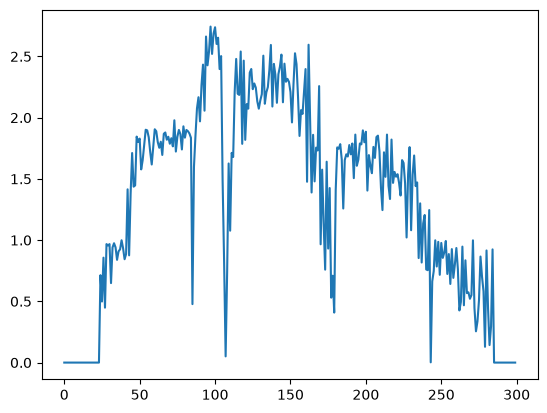

In [8]:
plt.plot(np.load("/home/shardul/transmission_results/consolidated_data/size_7/size_7_8.npy")[0])